# ReAct Agent Loop [Step 2 - Reason -> Tool -> Reason -> END Cycle]

> **MLCourse - Agentic AI - LangGraph**

This notebook builds a ReAct (Reasoning + Acting) agent from scratch using
LangGraph's StateGraph. We implement the reason -> tool -> reason -> END
cycle with iteration guards and error handling.

## 1. Setup and Imports

In [1]:
import os
import math
import json
import warnings
warnings.filterwarnings("ignore")
from dotenv import load_dotenv
load_dotenv()

False

## 2. Initialize the LLM

In [2]:
from langchain_ollama import ChatOllama
llm = ChatOllama(model="llama3.1:8b", temperature=0)
print("LLM initialized:", llm.model)

LLM initialized: llama3.1:8b


## 3. Define Tools

In [3]:
from langchain_core.tools import tool

@tool
def calculator(expression: str) -> str:
    """Evaluate a mathematical expression. Supports +, -, *, /, **, sqrt, sin, cos, tan, log, pi, e.
    Example: '2 + 3 * 4' or 'sqrt(16)'"""
    allowed_names = {
        "sqrt": math.sqrt, "sin": math.sin, "cos": math.cos,
        "tan": math.tan, "log": math.log,
        "pi": math.pi, "e": math.e, "abs": abs, "round": round,
    }
    try:
        result = eval(expression, {"__builtins__": {}}, allowed_names)
        return json.dumps({"result": result, "expression": expression})
    except Exception as ex:
        return json.dumps({"error": str(ex), "expression": expression})

@tool
def get_weather(city: str) -> str:
    """Get the current weather for a given city. Returns temperature and conditions."""
    mock_data = {
        "new york": {"temp": 22, "condition": "Sunny"},
        "london": {"temp": 15, "condition": "Cloudy"},
        "tokyo": {"temp": 28, "condition": "Partly Cloudy"},
    }
    key = city.lower().strip()
    if key in mock_data:
        d = mock_data[key]
        return json.dumps({"city": city, "temp": d["temp"], "condition": d["condition"]})
    return json.dumps({"error": f"No data for '{city}'"})

@tool
def search_knowledge(query: str) -> str:
    """Search a knowledge base for information. Use for factual questions."""
    kb = {
        "python": "Python is a high-level programming language created by Guido van Rossum in 1991.",
        "langchain": "LangChain is a framework for building LLM-powered applications with chains and agents.",
        "langgraph": "LangGraph is a library for building stateful, multi-actor applications with LLMs.",
    }
    query_lower = query.lower()
    for key, val in kb.items():
        if key in query_lower:
            return json.dumps({"answer": val, "source": "knowledge_base"})
    return json.dumps({"answer": "No relevant information found.", "source": "knowledge_base"})

tools = [calculator, get_weather, search_knowledge]
print(f"Registered {len(tools)} tools.")

Registered 3 tools.


## 4. Bind Tools to the LLM

In [4]:
llm_with_tools = llm.bind_tools(tools)
print("Tools bound to LLM.")

Tools bound to LLM.


## 5. Define the ReAct Agent State
The ReAct state tracks messages, iteration count, and max iterations.

In [5]:
from typing import TypedDict, Annotated, Literal
from langgraph.graph import StateGraph, MessagesState, END

class ReActState(TypedDict):
    """Custom state for the ReAct agent with iteration tracking."""
    messages: list
    iteration: int
    max_iterations: int

## 6. Define the Agent Node (Reasoning Step)
The agent node calls the LLM, increments the iteration counter,
and decides whether to use a tool or respond directly.

In [6]:
def react_agent(state: ReActState):
    """Reasoning step: call the LLM and track iterations."""
    messages = state["messages"]
    iteration = state.get("iteration", 0)
    max_iter = state.get("max_iterations", 5)

    print(f"  [Agent] Iteration {iteration + 1}/{max_iter}")

    response = llm_with_tools.invoke(messages)
    return {
        "messages": [response],
        "iteration": iteration + 1,
    }

## 7. Define the Tool Execution Node
Wraps ToolNode with error handling and logging.

In [7]:
from langgraph.prebuilt import ToolNode

tool_node = ToolNode(tools)

def safe_tool_executor(state: ReActState):
    """Execute tools with error handling. Catches exceptions and returns error messages."""
    print(f"  [Tools] Executing tool calls...")
    try:
        result = tool_node.invoke(state)
        tool_msgs = result.get("messages", [])
        for msg in tool_msgs:
            if hasattr(msg, "name"):
                content = msg.content[:100] if isinstance(msg.content, str) else str(msg.content)[:100]
                print(f"  [Tools] {msg.name} -> {content}")
        return result
    except Exception as ex:
        error_msg = f"Tool execution error: {str(ex)}"
        print(f"  [Tools] ERROR: {error_msg}")
        from langchain_core.messages import AIMessage, ToolMessage
        return {"messages": [ToolMessage(content=error_msg, tool_call_id="error")]}

## 8. Define Routing Logic
Custom routing checks iteration count and whether the LLM called tools.

In [8]:
def should_continue(state: ReActState) -> Literal["tools", "__end__"]:
    """Route: if agent called tools, go to tools. Otherwise, END."""
    last_msg = state["messages"][-1]
    iteration = state.get("iteration", 0)
    max_iter = state.get("max_iterations", 5)

    # Check iteration guard
    if iteration >= max_iter:
        print(f"  [Router] Max iterations ({max_iter}) reached. Ending.")
        return "__end__"

    # Check if the last message has tool calls
    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        print(f"  [Router] Tool calls detected. Routing to tools.")
        return "tools"

    print(f"  [Router] No tool calls. Ending.")
    return "__end__"

## 9. Build the ReAct Graph from Scratch

In [9]:
graph_builder = StateGraph(ReActState)

# Add nodes
graph_builder.add_node("agent", react_agent)
graph_builder.add_node("tools", safe_tool_executor)

# Set entry point
graph_builder.set_entry_point("agent")

# Add conditional edge using our custom router
graph_builder.add_conditional_edges(
    "agent",
    should_continue,
    {"tools": "tools", "__end__": END},
)

# Tools loop back to agent
graph_builder.add_edge("tools", "agent")

## 10. Compile and Visualize

ReAct agent graph compiled.


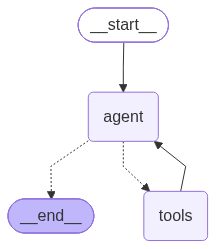

In [10]:
graph = graph_builder.compile()
print("ReAct agent graph compiled.")

from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not render graph image: {e}")
    print("Graph structure:")
    print("  Entry -> agent")
    print("  agent -> [should_continue] -> tools (if tool calls) or END")
    print("  tools -> agent (loop)")
    print("  Iteration guard: max 5 loops")

## 11. Run: Simple Reasoning (No Tools Needed)

In [11]:
print("=== Test 1: Direct response (no tools needed) ===")
result = graph.invoke({
    "messages": [{"role": "user", "content": "What is the capital of France?"}],
    "iteration": 0,
    "max_iterations": 5,
})
for msg in result["messages"]:
    role = msg.__class__.__name__
    content = msg.content if isinstance(msg.content, str) else str(msg.content)
    print(f"  [{role}]: {content[:150]}")
print(f"  Total iterations: {result['iteration']}")

=== Test 1: Direct response (no tools needed) ===
  [Agent] Iteration 1/5


  [Router] Tool calls detected. Routing to tools.
  [Tools] Executing tool calls...
  [Tools] search_knowledge -> {"answer": "No relevant information found.", "source": "knowledge_base"}
  [Agent] Iteration 2/5


  [Router] No tool calls. Ending.
  [AIMessage]: I'm sorry, but I couldn't find any relevant information to assist you with your query. Can you please provide more context or clarify your question so
  Total iterations: 2


## 12. Run: Tool-Using ReAct Loop

In [12]:
print("=== Test 2: Tool-using ReAct loop ===")
result = graph.invoke({
    "messages": [{"role": "user", "content": "What is sqrt(144) + cos(0)?"}],
    "iteration": 0,
    "max_iterations": 5,
})
print()
for msg in result["messages"]:
    role = msg.__class__.__name__
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        print(f"  [{role}] calls: {msg.tool_calls}")
    elif hasattr(msg, "name") and msg.name:
        content = msg.content[:150] if isinstance(msg.content, str) else str(msg.content)[:150]
        print(f"  [{role}] ({msg.name}): {content}")
    else:
        content = msg.content if isinstance(msg.content, str) else str(msg.content)
        print(f"  [{role}]: {content[:200]}")
print(f"  Total iterations: {result['iteration']}")

=== Test 2: Tool-using ReAct loop ===
  [Agent] Iteration 1/5


  [Router] Tool calls detected. Routing to tools.
  [Tools] Executing tool calls...
  [Tools] calculator -> {"result": 13.0, "expression": "sqrt(144) + cos(0)"}
  [Agent] Iteration 2/5


  [Router] No tool calls. Ending.

  [AIMessage]: The square root of 144 is 12. The cosine of 0 degrees is 1. Therefore, the result of the expression sqrt(144) + cos(0) is 13.
  Total iterations: 2


## 13. Run: Multi-Step Reasoning

In [13]:
print("=== Test 3: Multi-step reasoning ===")
result = graph.invoke({
    "messages": [{"role": "user", "content": "What is the weather in London and what is 5 factorial?"}],
    "iteration": 0,
    "max_iterations": 5,
})
print()
for msg in result["messages"]:
    role = msg.__class__.__name__
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        for tc in msg.tool_calls:
            print(f"  [{role}] calls: {tc['name']}({tc['args']})")
    elif hasattr(msg, "name") and msg.name:
        content = msg.content[:150] if isinstance(msg.content, str) else str(msg.content)[:150]
        print(f"  [{role}] ({msg.name}): {content}")
    else:
        content = msg.content if isinstance(msg.content, str) else str(msg.content)
        print(f"  [{role}]: {content[:200]}")
print(f"  Total iterations: {result['iteration']}")

=== Test 3: Multi-step reasoning ===
  [Agent] Iteration 1/5


  [Router] Tool calls detected. Routing to tools.
  [Tools] Executing tool calls...
  [Tools] get_weather -> {"city": "London", "temp": 15, "condition": "Cloudy"}
  [Tools] calculator -> {"result": 120, "expression": "5 * 4 * 3 * 2 * 1"}
  [Agent] Iteration 2/5


  [Router] No tool calls. Ending.

  [AIMessage]: The temperature in London is currently 15 degrees Celsius and the condition is Cloudy. 

The result of the expression '5 * 4 * 3 * 2 * 1' is 120.
  Total iterations: 2


## 14. Demonstrate Iteration Guard

In [14]:
print("=== Test 4: Iteration guard (max_iterations=2) ===")
result = graph.invoke({
    "messages": [{"role": "user", "content": "Calculate sqrt(2), then sqrt(3), then sqrt(5)"}],
    "iteration": 0,
    "max_iterations": 2,
})
print()
print(f"  Final iteration count: {result['iteration']}")
print(f"  Max was set to: 2")
if result["iteration"] >= 2:
    print("  Iteration guard was triggered correctly.")

=== Test 4: Iteration guard (max_iterations=2) ===
  [Agent] Iteration 1/2


  [Router] Tool calls detected. Routing to tools.
  [Tools] Executing tool calls...
  [Tools] calculator -> {"result": 1.4142135623730951, "expression": "sqrt(2)"}
  [Tools] calculator -> {"result": 1.7320508075688772, "expression": "sqrt(3)"}
  [Tools] calculator -> {"result": 2.23606797749979, "expression": "sqrt(5)"}
  [Agent] Iteration 2/2


  [Router] Max iterations (2) reached. Ending.

  Final iteration count: 2
  Max was set to: 2
  Iteration guard was triggered correctly.


## 15. Inspect the Graph Structure

In [15]:
print("=== Graph Structure ===")
g = graph.get_graph()
print(f"Nodes: {list(g.nodes.keys())}")
print(f"Edges:")
for edge in g.edges:
    print(f"  {edge.source} -> {edge.target}")

=== Graph Structure ===
Nodes: ['__start__', 'agent', 'tools', '__end__']
Edges:
  __start__ -> agent
  agent -> __end__
  agent -> tools
  tools -> agent


## Summary

Key takeaways:
- ReAct loop: reason (LLM) -> act (tools) -> reason -> ... -> END
- Iteration guards prevent infinite loops (critical for production)
- Error handling in tool execution prevents crashes
- Custom state tracks iteration count alongside messages
- The router decides: call tools again or finish